# Temporal Diffusion Model - Interactive Analysis

This notebook provides interactive analysis for:
1. Loading trained diffusion models
2. Generating samples
3. Visualizing results
4. Comparing with training data
5. Evaluating sample quality


## Setup


In [1]:
import numpy as np
import torch as th
import matplotlib.pyplot as plt
from pathlib import Path
import json
from tqdm.auto import tqdm

# Import diffusion model utilities
from improved_diffusion.temporal_script_util import (
    create_temporal_model_and_diffusion,
    temporal_model_and_diffusion_defaults,
)
from improved_diffusion import dist_util

# Set random seed for reproducibility
th.manual_seed(42)
np.random.seed(42)

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Imports successful")
print(f"Using device: {dist_util.dev()}")

✓ Imports successful
Using device: cuda:0


## 1. Configuration

**IMPORTANT:** Make sure these parameters match your training configuration!


In [2]:
# === MODIFY THESE PATHS ===
MODEL_PATH = "logs/model030000.pt"  # or "logs/ema_0.9999_030000.pt" for EMA model
TRAINING_DATA_PATH = "examples/data/log_flux_dataset.pt"  # Optional: for comparison

# === MODEL ARCHITECTURE (must match training!) ===
SEQUENCE_LENGTH = 1024
NUM_CHANNELS = 64
NUM_RES_BLOCKS = 2
ATTENTION_RESOLUTIONS = "32, 16"
CHANNEL_MULT = "1, 2, 3, 4"
DIFFUSION_STEPS = 1000
NOISE_SCHEDULE = "linear"

# === TIME SCALE CONFIGURATION ===
# Total duration in seconds
TIME_DURATION = 2.0 
# Hz (samples per second)
SAMPLING_RATE = SEQUENCE_LENGTH / TIME_DURATION

# === SAMPLING CONFIGURATION ===
# Number of samples to generate
NUM_SAMPLES = 100 
# Faster sampling
USE_DDIM = True  
# Use 50 steps instead of 1000 for speed
TIMESTEP_RESPACING = "50"  

print("Configuration:")
print(f"  Model: {MODEL_PATH}")
print(f"  Sequence length: {SEQUENCE_LENGTH}")
print(f"  Num channels: {NUM_CHANNELS}")
print(f"  Time duration: {TIME_DURATION} seconds")
print(f"  Sampling rate: {SAMPLING_RATE:.1f} Hz")
print(f"  Samples to generate: {NUM_SAMPLES}")
print(f"  Use DDIM: {USE_DDIM}")
if USE_DDIM:
    print(f"  DDIM steps: {TIMESTEP_RESPACING}")


Configuration:
  Model: logs/model030000.pt
  Sequence length: 1024
  Num channels: 64
  Time duration: 2.0 seconds
  Sampling rate: 512.0 Hz
  Samples to generate: 100
  Use DDIM: True
  DDIM steps: 50


## 2. Load Trained Model


In [3]:
print("Creating model architecture...")

# Create model with same architecture as training
model, diffusion = create_temporal_model_and_diffusion(
    sequence_length = SEQUENCE_LENGTH,
    num_channels = NUM_CHANNELS,
    num_res_blocks = NUM_RES_BLOCKS,
    num_heads = 4,
    num_heads_upsample = -1,
    attention_resolutions = ATTENTION_RESOLUTIONS,
    channel_mult = CHANNEL_MULT,
    dropout = 0.0,
    learn_sigma = False,
    sigma_small = False,
    diffusion_steps = DIFFUSION_STEPS,
    noise_schedule = NOISE_SCHEDULE,
    timestep_respacing = TIMESTEP_RESPACING if USE_DDIM else "",
    use_kl = False,
    predict_xstart = False,
    rescale_timesteps = True,
    rescale_learned_sigmas = True,
    use_checkpoint = False,
    use_scale_shift_norm = True,
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Model created: {total_params:,} parameters")

# Load checkpoint
print(f"Loading checkpoint from: {MODEL_PATH}")
try:
    state_dict = th.load(MODEL_PATH, map_location = dist_util.dev())
    model.load_state_dict(state_dict)
    model.to(dist_util.dev())
    model.eval()
    print("✓ Model loaded successfully!")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    print("\nPossible issues:")
    print("  1. Wrong model path - check that the file exists")
    print("  2. Architecture mismatch - verify SEQUENCE_LENGTH, NUM_CHANNELS, etc. match training")
    print("  3. Using optimizer checkpoint (opt*.pt) instead of model checkpoint (model*.pt)")
    raise


Creating model architecture...
✓ Model created: 9,050,433 parameters
Loading checkpoint from: logs/model030000.pt


/tmp/ipykernel_346573/1021177239.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = th.load(MODEL_PATH, map_location = dist_util.dev())


✓ Model loaded successfully!


## 3. Generate Samples


In [4]:
print(f"Generating {NUM_SAMPLES} samples...")
print(f"Sampling method: {'DDIM' if USE_DDIM else 'DDPM'}")

sample_shape = (NUM_SAMPLES, 1, SEQUENCE_LENGTH)

with th.no_grad():
    if USE_DDIM:
        # Fast DDIM sampling
        samples = diffusion.ddim_sample_loop(
            model,
            sample_shape,
            clip_denoised = True,
            progress = True,
            device = dist_util.dev(),
        )
    else:
        # Standard DDPM sampling (slower but potentially higher quality)
        samples = diffusion.p_sample_loop(
            model,
            sample_shape,
            clip_denoised = True,
            progress = True,
            device = dist_util.dev(),
        )

# Move to CPU and convert to numpy
samples = samples.cpu().numpy()

print(f"✓ Generated {samples.shape[0]} samples")
print(f"  Shape: {samples.shape}")
print(f"  Range: [{samples.min():.3f}, {samples.max():.3f}]")
print(f"  Mean: {samples.mean():.3f}, Std: {samples.std():.3f}")


Generating 100 samples...
Sampling method: DDIM


  0%|          | 0/50 [00:00<?, ?it/s]

✓ Generated 100 samples
  Shape: (100, 1, 1024)
  Range: [-1.000, 1.000]
  Mean: 0.269, Std: 0.491


## 4. Denormalize Samples Back to Original Scale

⚠️ **The model outputs normalized data in [-1, 1]!**  
You MUST denormalize to get back to the original log-flux scale.


In [5]:
# ============================================================================
# DENORMALIZATION: Convert from normalized [-1, 1] to original log-flux scale
# ============================================================================
print("⚠️  Generated samples are in NORMALIZED range [-1, 1]")
print(f"  Current range: [{samples.min():.3f}, {samples.max():.3f}]")
training_data = th.load(TRAINING_DATA_PATH)

if isinstance(training_data, th.Tensor):
    training_data = training_data.numpy()
elif isinstance(training_data, np.ndarray):
    pass
else:
    raise ValueError(f"Unexpected training data type: {type(training_data)}")

# Get original data range
data_min = float(training_data.min())
data_max = float(training_data.max())

print(f"✓ Loaded training data")
print(f"  Shape: {training_data.shape}")
print(f"  Original range: [{data_min:.4f}, {data_max:.4f}]")

# Denormalize: reverse the normalization process
# Training normalization: x_norm = (x - min) / (max - min) * 2 - 1
# Denormalization: x = ((x_norm + 1) / 2) * (max - min) + min

samples_denorm = ((samples + 1) / 2) * (data_max - data_min) + data_min

print(f"\n✓ Denormalized samples!")
print(f"  Denormalized range: [{samples_denorm.min():.4f}, {samples_denorm.max():.4f}]")
print(f"  Expected range: [{data_min:.4f}, {data_max:.4f}]")

# Replace samples with denormalized version
samples = samples_denorm

print(f"\nSamples are now in LOG-FLUX space:")
print(f"  Shape: {samples.shape}")
print(f"  Range: [{samples.min():.4f}, {samples.max():.4f}]")
print(f"  Mean: {samples.mean():.4f}, Std: {samples.std():.4f}")


⚠️  Generated samples are in NORMALIZED range [-1, 1]
  Current range: [-1.000, 1.000]


/tmp/ipykernel_346573/3510421441.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  training_data = th.load(TRAINING_DATA_PATH)


✓ Loaded training data
  Shape: (50000, 1024)
  Original range: [2.3026, 9.2103]

✓ Denormalized samples!
  Denormalized range: [2.3026, 9.2103]
  Expected range: [2.3026, 9.2103]

Samples are now in LOG-FLUX space:
  Shape: (100, 1, 1024)
  Range: [2.3026, 9.2103]
  Mean: 6.6857, Std: 1.6975


## 5. Convert from Log-Space to Linear Space (Flux Recovery)

If your training data was in **log-space** (i.e., log φ(t)), convert back to linear space to get the actual flux φ(t).


⚠️  Data appears to be in LOG-SPACE
Converting to linear space: φ(t) = exp(x_0)...

Log-space statistics:
  Range: [2.303, 9.210]
  Mean: 6.686, Std: 1.697

Linear-space (flux) statistics:
  Range: [10.0, 10000.0] photons/sec
  Mean: 1834.8, Std: 1837.3 photons/sec


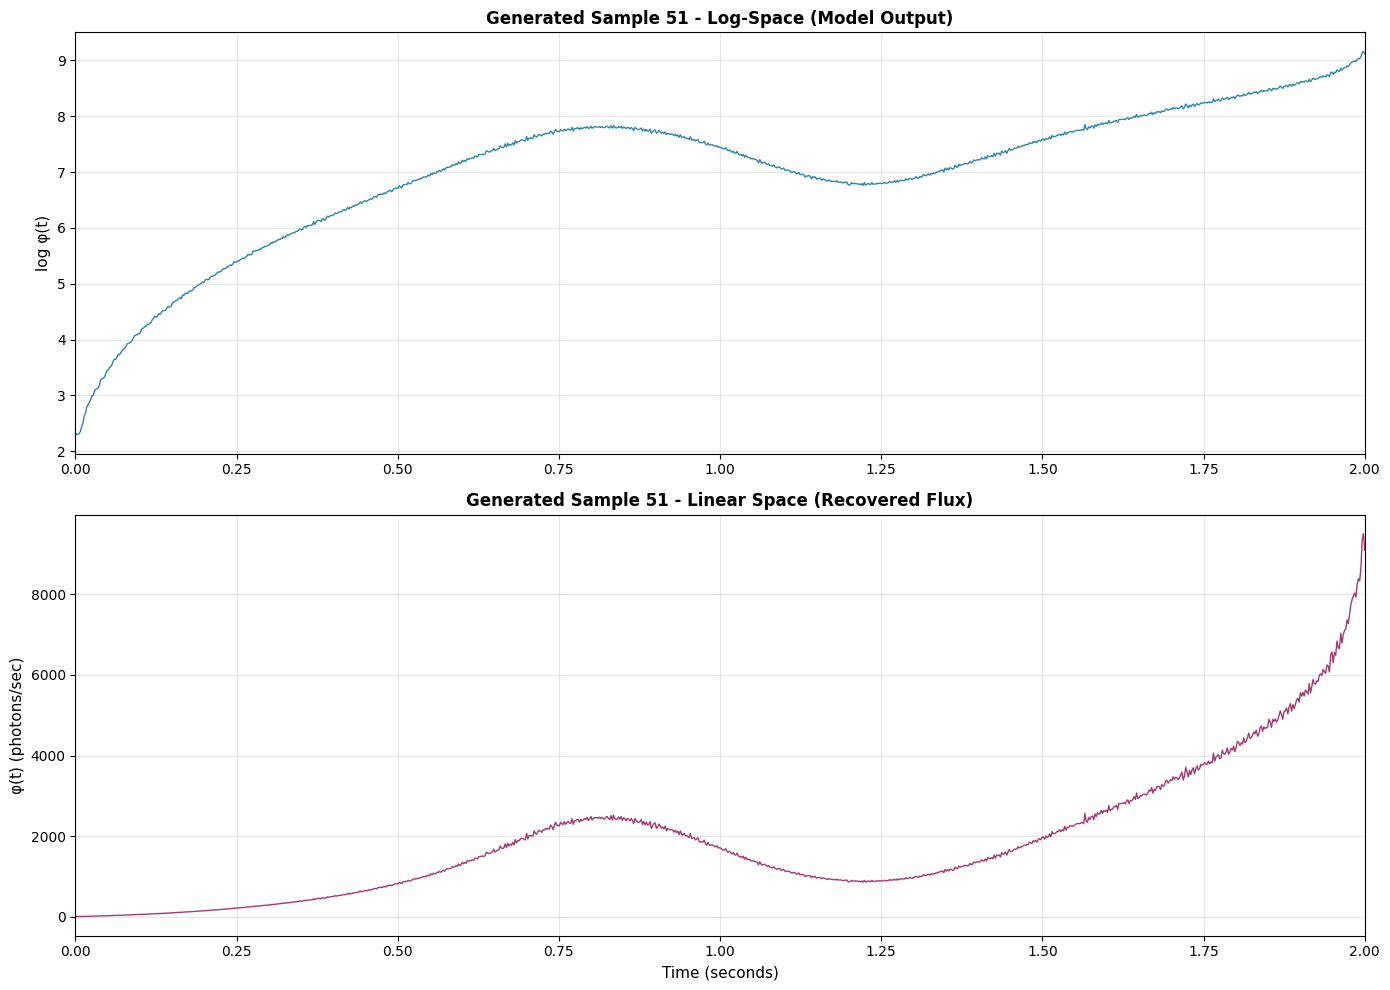


✓ Created 'flux_samples' variable with recovered flux values
  Use 'flux_samples' instead of 'samples' for photon flux analysis


In [6]:
# Check if data is in log-space (heuristic: if values are roughly in [-10, 10] range, likely log-space)
is_log_space = (samples.min() > -20) and (samples.max() < 20) and (samples.mean() < 10)

if is_log_space:
    print("⚠️  Data appears to be in LOG-SPACE")
    print("Converting to linear space: φ(t) = exp(x_0)...\n")
    
    # Convert from log-space to linear space
    flux_samples = np.exp(samples)
    
    print("Log-space statistics:")
    print(f"  Range: [{samples.min():.3f}, {samples.max():.3f}]")
    print(f"  Mean: {samples.mean():.3f}, Std: {samples.std():.3f}")
    
    print("\nLinear-space (flux) statistics:")
    print(f"  Range: [{flux_samples.min():.1f}, {flux_samples.max():.1f}] photons/sec")
    print(f"  Mean: {flux_samples.mean():.1f}, Std: {flux_samples.std():.1f} photons/sec")
    
    # Plot comparison: log-space vs linear-space
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Random sample to compare
    idx = np.random.randint(0, NUM_SAMPLES)
    t = np.linspace(0, TIME_DURATION, SEQUENCE_LENGTH)
    
    # Log-space (what the model generated)
    axes[0].plot(t, samples[idx, 0, :], linewidth=1.0, color='#2E86AB')
    axes[0].set_ylabel('log φ(t)', fontsize=11)
    axes[0].set_title(f'Generated Sample {idx} - Log-Space (Model Output)', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, TIME_DURATION)
    
    # Linear-space (recovered flux)
    axes[1].plot(t, flux_samples[idx, 0, :], linewidth=1.0, color='#A23B72')
    axes[1].set_xlabel(f'Time (seconds)', fontsize=11)
    axes[1].set_ylabel('φ(t) (photons/sec)', fontsize=11)
    axes[1].set_title(f'Generated Sample {idx} - Linear Space (Recovered Flux)', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, TIME_DURATION)
    
    plt.tight_layout()
    # plt.savefig('log_vs_linear_comparison.png', dpi=150, bbox_inches='tight')
    # print("\nSaved: log_vs_linear_comparison.png")
    plt.show()
    
    # Store flux samples for later use
    print("\n✓ Created 'flux_samples' variable with recovered flux values")
    print("  Use 'flux_samples' instead of 'samples' for photon flux analysis")
    
else:
    print("✓ Data appears to be in LINEAR SPACE already")
    print("No conversion needed.")
    flux_samples = samples  # Already in linear space


## 6. Visualize Recovered Flux Patterns (Linear Space)


Saved: flux_patterns_linear.png


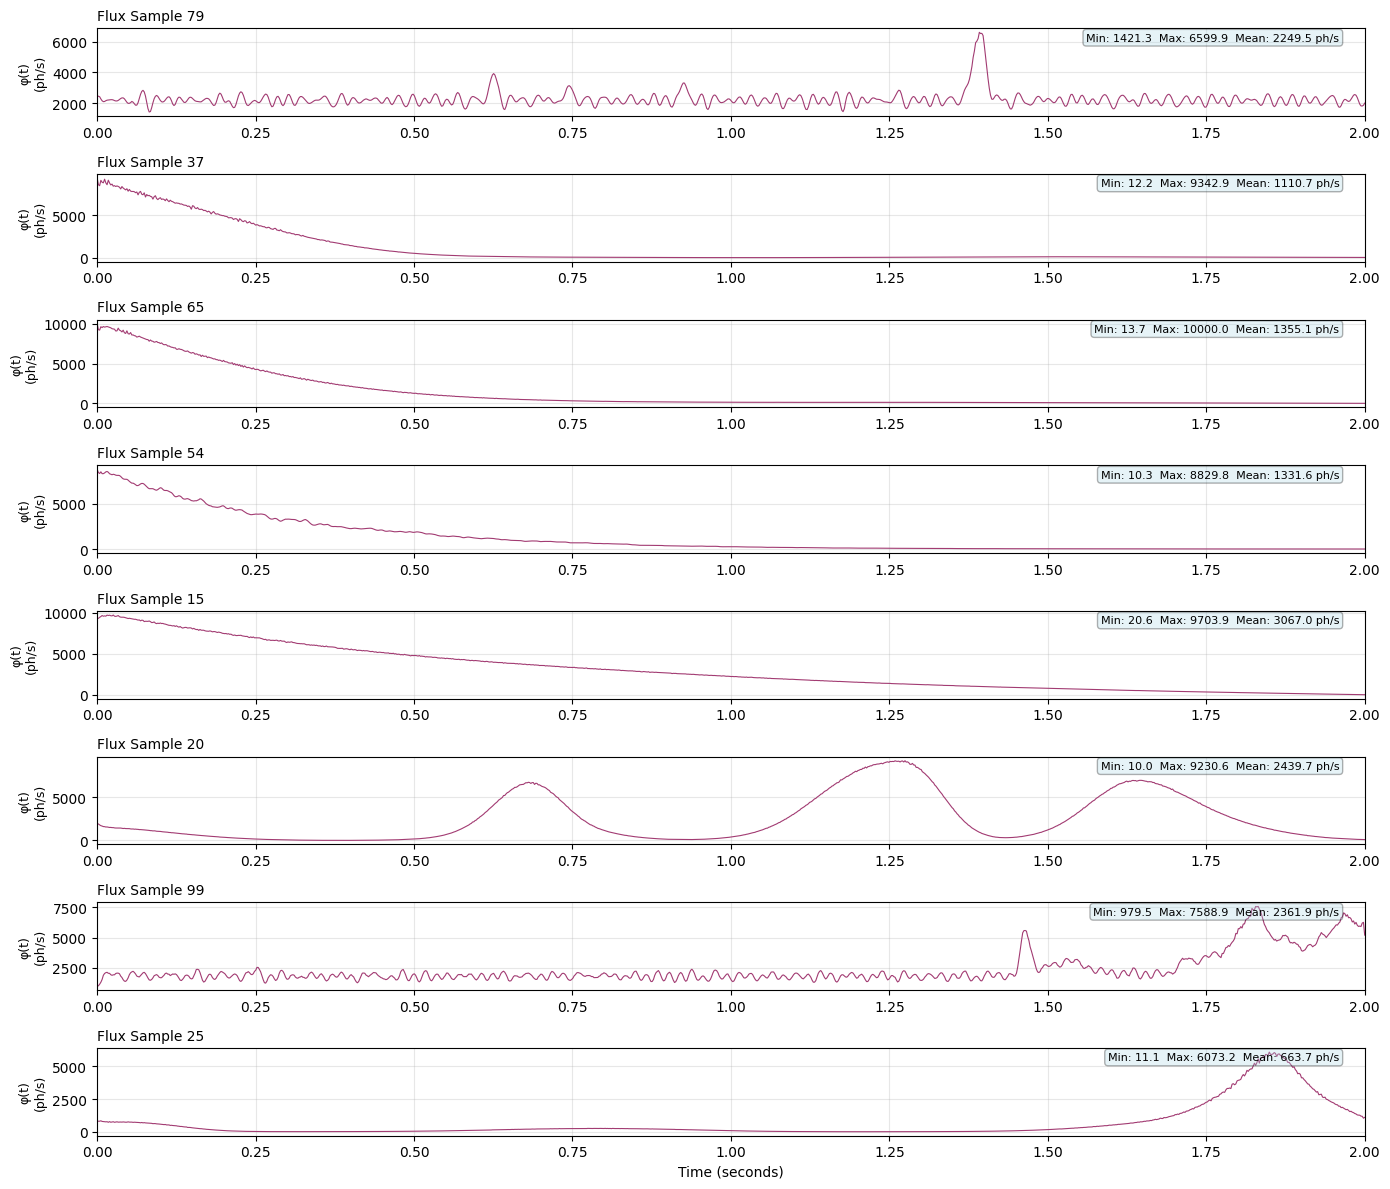


Flux Statistics (Linear Space):
  Average flux: 1834.8 ± 1837.3 photons/sec
  Flux range: [10.0, 10000.0] photons/sec
  Mean flux per sample: 1834.8 ± 1108.9 photons/sec


In [8]:
# Plot multiple flux samples in linear space
num_plots = 8
indices = np.random.choice(NUM_SAMPLES, num_plots, replace=False)

fig, axes = plt.subplots(num_plots, 1, figsize=(14, 1.5*num_plots))
if num_plots == 1:
    axes = [axes]

t = np.linspace(0, TIME_DURATION, SEQUENCE_LENGTH)

for i, idx in enumerate(indices):
    flux = flux_samples[idx, 0, :]
    
    axes[i].plot(t, flux, linewidth=0.8, color='#A23B72')
    axes[i].set_ylabel('φ(t)\n(ph/s)', fontsize=9)
    axes[i].set_title(f'Flux Sample {idx}', fontsize=10, loc='left')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(0, TIME_DURATION)
    
    # Add statistics
    stats_text = f"Min: {flux.min():.1f}  Max: {flux.max():.1f}  Mean: {flux.mean():.1f} ph/s"
    axes[i].text(0.98, 0.95, stats_text, transform=axes[i].transAxes,
                fontsize=8, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    
    if i == num_plots - 1:
        axes[i].set_xlabel(f'Time (seconds)', fontsize=10)

plt.tight_layout()
plt.savefig('flux_patterns_linear.png', dpi=150, bbox_inches='tight')
print("Saved: flux_patterns_linear.png")
plt.show()

# Print flux statistics
print("\nFlux Statistics (Linear Space):")
flux_means = flux_samples[:, 0, :].mean(axis=1)
flux_stds = flux_samples[:, 0, :].std(axis=1)
print(f"  Average flux: {flux_samples.mean():.1f} ± {flux_samples.std():.1f} photons/sec")
print(f"  Flux range: [{flux_samples.min():.1f}, {flux_samples.max():.1f}] photons/sec")
print(f"  Mean flux per sample: {flux_means.mean():.1f} ± {flux_means.std():.1f} photons/sec")


## Log-Space ↔ Linear-Space:

**Training Data Transformation:**
```
Original flux: φ(t) ∈ [10, 10000] photons/sec  (wide range, multiplicative noise)
                ↓ log transform
Log-space: x = log φ(t) ∈ [2.3, 9.2]  (compact, additive noise ✓ good for diffusion)
                ↓ train diffusion model
Model generates: x₀ = log φ(t)
                ↓ exponential transform
Recovered flux: φ(t) = exp(x₀)  (original photon flux!)
```

**Why log-space?**
1. Compresses wide dynamic range
2. Converts multiplicative noise → additive noise
3. Better for diffusion model training
4. Standard practice in photon imaging